# Synthetic Occlusion Experiment on DMD

**Purpose:** Evaluate how the ROF-trained occlusion estimator responds to *controlled* synthetic occlusions applied to DMD frames.

The [occlusion estimator audit](occlusion_estimator_audit.ipynb) showed that the estimator produces near-zero probabilities on real DMD frames (AUC ≈ 0.56 for eyes, 0.67 for mouth). The hypothesis is that this is a **domain gap** — the estimator was trained on ROF data with sunglasses and masks, while DMD has prescription glasses and hand-over-mouth.

**This experiment answers:**
1. When we apply ROF-style synthetic occlusions (dark band = sunglasses, light rect = mask) to DMD frames, does the estimator produce **stronger** occlusion signals?
2. How does `p_eye` and `p_mouth` increase as a function of occlusion opacity?
3. At what opacity level does the estimator reliably detect the occlusion?
4. Is the response **region-specific** (i.e., eye occlusion raises `p_eye` but not `p_mouth`)?

**Key insight for journal:** If the estimator responds correctly to ROF-style occlusions on DMD faces, the gating architecture is sound — the bottleneck is the domain mismatch in occlusion types.

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150

print('Imports ready.')

Imports ready.


In [2]:
from occlusion_audit_utils import (
    CONFIG,
    load_csv_video_data,
    FaceDetector,
    ResNet34OcclusionModel,
    sample_frames_for_audit,
)

from synthetic_occlusion_utils import (
    apply_synthetic_occlusion,
    apply_eye_band,
    apply_mouth_rect,
    OPACITY_LEVELS,
)

print('All utilities loaded.')

All utilities loaded.


## 1. Load Annotations & Initialise Models

In [3]:
csv_data = load_csv_video_data(CONFIG['CSV_DATASET_PATH'], filter_eye_states=True)
print(f"\nLoaded {len(csv_data)} videos from {len(set(m['subject'] for m in csv_data.values()))} subjects.")

Loading CSV video data from: Data
  Sub1_sub1_video: 4256 frames (filtered 1224)
  Sub10_sub10_video: 4440 frames (filtered 1615)
  Sub11_sub11_video: 4049 frames (filtered 1328)
  Sub12_sub12_video: 4562 frames (filtered 1014)
  Sub13_sub13_video: 4246 frames (filtered 1134)
  Sub14_sub14_video: 4585 frames (filtered 929)
  Sub15_sub15_video: 3957 frames (filtered 1337)
  Sub2_sub2_video: 4218 frames (filtered 1198)
  Sub3_sub3_video: 3463 frames (filtered 2064)
  Sub4_sub4_video: 3829 frames (filtered 1400)
  Sub5_sub5_video: 3642 frames (filtered 1645)
  Sub6_sub6_video: 4031 frames (filtered 1379)
  Sub7_sub7_video: 3708 frames (filtered 1697)
  Sub8_sub8_video: 4345 frames (filtered 1062)
  Sub9_sub9_video: 3977 frames (filtered 1315)

Loaded 15 videos from 15 subjects.


In [4]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

face_detector = FaceDetector(
    shape_model_path=CONFIG['DLIB_MODEL_PATH'],
    det_size=(768, 768),
    det_thresh=0.35,
)

occ_model = ResNet34OcclusionModel(
    ckpt_path=CONFIG['RESNET34_OCCLUSION_MODEL_PATH'],
    device=device,
)

print(f'\nBoth models initialised on {device}.')

Using device: cpu
Initializing RetinaFace detector...
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/mehaksaleem/.insightface/models/buffalo_sc/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/mehaksaleem/.insightface/models/buffalo_sc/w600k_mbf.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (768, 768)
  RetinaFace (buffalo_sc) + dlib 68pt ready  [thresh=0.35]

Both models initialised on cpu.


## 2. Sample Frames

We sample a modest number of frames per subject. Synthetic occlusion is applied on-the-fly so the bottleneck is face-detection + model inference, not storage.

Set `MAX_PER_SUBJECT = None` for all frames (GPU), or an integer (e.g. 30) for quick CPU testing.

In [5]:
# Set to None for ALL frames (GPU), or a number for quick CPU testing
MAX_PER_SUBJECT = 30

print(f"Sampling frames (max {MAX_PER_SUBJECT} per subject) ...")
sampled = sample_frames_for_audit(
    csv_data,
    max_per_subject=MAX_PER_SUBJECT,
    include_all_occluded=True,
    seed=42,
)

total_sampled = sum(len(v) for v in sampled.values())
print(f"\nTotal: {total_sampled} frames across {len(sampled)} videos")

Sampling frames (max 30 per subject) ...
  Sub1_sub1_video: 30 occluded + 0 non-occluded = 30 frames
  Sub10_sub10_video: 2 occluded + 28 non-occluded = 30 frames
  Sub11_sub11_video: 1 occluded + 29 non-occluded = 30 frames
  Sub12_sub12_video: 1 occluded + 29 non-occluded = 30 frames
  Sub13_sub13_video: 1 occluded + 29 non-occluded = 30 frames
  Sub14_sub14_video: 1 occluded + 29 non-occluded = 30 frames
  Sub15_sub15_video: 30 occluded + 0 non-occluded = 30 frames
  Sub2_sub2_video: 1 occluded + 29 non-occluded = 30 frames
  Sub3_sub3_video: 1 occluded + 29 non-occluded = 30 frames
  Sub4_sub4_video: 1 occluded + 29 non-occluded = 30 frames
  Sub5_sub5_video: 1 occluded + 29 non-occluded = 30 frames
  Sub6_sub6_video: 1 occluded + 29 non-occluded = 30 frames
  Sub7_sub7_video: 1 occluded + 29 non-occluded = 30 frames
  Sub8_sub8_video: 2 occluded + 28 non-occluded = 30 frames
  Sub9_sub9_video: 1 occluded + 29 non-occluded = 30 frames

Total: 450 frames across 15 videos


## 3. Run Estimator at Multiple Opacity Levels

For each sampled frame we:
1. Read the original frame from video.
2. Detect face and extract dlib landmarks.
3. For **each opacity level** in `[0.0, 0.3, 0.5, 0.7, 0.9, 1.0]`:
   - Apply **eye-only** synthetic occlusion → run estimator → record `p_eye`, `p_mouth`.
   - Apply **mouth-only** synthetic occlusion → run estimator → record `p_eye`, `p_mouth`.
   - Apply **both** synthetic occlusions → run estimator → record `p_eye`, `p_mouth`.

This produces a rich dataset: `n_frames × n_opacity_levels × 3 occlusion_types`.

In [6]:
import time

opacity_levels = OPACITY_LEVELS  # [0.0, 0.3, 0.5, 0.7, 0.9, 1.0]

occlusion_configs = [
    ('none',       0.0, 0.0),
    ('eye_only',   1.0, 0.0),   # eye_opacity replaced per-level below
    ('mouth_only', 0.0, 1.0),   # mouth_opacity replaced per-level below
    ('both',       1.0, 1.0),   # both replaced per-level below
]

rows = []
total = sum(len(v) for v in sampled.values())
processed = 0
t_start = time.time()

for video_key, ann_list in sampled.items():
    meta = csv_data[video_key]
    cap = cv2.VideoCapture(meta['video_path'])
    if not cap.isOpened():
        print(f"  [SKIP] Cannot open {meta['video_path']}")
        continue

    subject = meta['subject']
    print(f"  Processing {video_key} ({len(ann_list)} frames) ...")

    for ann in ann_list:
        cap.set(cv2.CAP_PROP_POS_FRAMES, ann.frame)
        ret, frame_bgr = cap.read()
        if not ret:
            continue

        det = face_detector.detect_face_and_landmarks(frame_bgr)
        if not det['is_valid']:
            continue

        landmarks = det['landmarks']
        face_bbox = det['face_bbox']
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

        for opacity in opacity_levels:
            for occ_name, eye_flag, mouth_flag in occlusion_configs:
                if occ_name == 'none' and opacity > 0.0:
                    continue
                if occ_name != 'none' and opacity == 0.0:
                    continue

                eo = opacity if eye_flag > 0 else 0.0
                mo = opacity if mouth_flag > 0 else 0.0

                if occ_name == 'none':
                    aug_rgb = frame_rgb
                else:
                    aug_rgb = apply_synthetic_occlusion(
                        frame_rgb, landmarks,
                        eye_opacity=eo, mouth_opacity=mo,
                    )

                probs = occ_model.predict_probs(
                    aug_rgb,
                    face_bbox=face_bbox,
                    image_bgr=False,
                    face_margin=0.15,
                )

                rows.append({
                    'subject': subject,
                    'video_key': video_key,
                    'frame': ann.frame,
                    'class_label': ann.class_label,
                    'occlusion_type': occ_name,
                    'opacity': opacity if occ_name != 'none' else 0.0,
                    'eye_opacity_applied': eo,
                    'mouth_opacity_applied': mo,
                    'p_eye': float(probs[0]),
                    'p_mouth': float(probs[1]),
                })

        processed += 1
        if processed % 50 == 0:
            elapsed = time.time() - t_start
            rate = processed / elapsed
            eta = (total - processed) / rate if rate > 0 else 0
            print(f"    [{processed}/{total}] {rate:.1f} frames/s, ETA {eta:.0f}s")

    cap.release()

elapsed = time.time() - t_start
print(f"\nDone: {processed}/{total} frames × {len(opacity_levels)} opacity levels in {elapsed:.0f}s")

df = pd.DataFrame(rows)
df.to_csv('synthetic_occlusion_results.csv', index=False)
print(f"Saved {len(df)} rows to synthetic_occlusion_results.csv")
df.head(10)

  Processing Sub1_sub1_video (30 frames) ...
  Processing Sub10_sub10_video (30 frames) ...
    [50/450] 2.2 frames/s, ETA 183s
  Processing Sub11_sub11_video (30 frames) ...
  Processing Sub12_sub12_video (30 frames) ...
    [100/450] 2.2 frames/s, ETA 163s
  Processing Sub13_sub13_video (30 frames) ...
    [150/450] 2.1 frames/s, ETA 141s
  Processing Sub14_sub14_video (30 frames) ...
  Processing Sub15_sub15_video (30 frames) ...
    [200/450] 2.1 frames/s, ETA 120s
  Processing Sub2_sub2_video (30 frames) ...
  Processing Sub3_sub3_video (30 frames) ...
    [250/450] 2.1 frames/s, ETA 97s
  Processing Sub4_sub4_video (30 frames) ...
    [300/450] 2.0 frames/s, ETA 73s
  Processing Sub5_sub5_video (30 frames) ...
  Processing Sub6_sub6_video (30 frames) ...
    [350/450] 2.0 frames/s, ETA 49s
  Processing Sub7_sub7_video (30 frames) ...
  Processing Sub8_sub8_video (30 frames) ...
    [400/450] 2.0 frames/s, ETA 25s
  Processing Sub9_sub9_video (30 frames) ...
    [450/450] 2.0 fram

,subject,video_key,frame,class_label,occlusion_type,opacity,eye_opacity_applied,mouth_opacity_applied,p_eye,p_mouth
0,Sub1,Sub1_sub1_video,117,Neutral,none,0.0,0.0,0.0,0.000497,0.000207
1,Sub1,Sub1_sub1_video,117,Neutral,eye_only,0.3,0.3,0.0,0.002629,0.000414
2,Sub1,Sub1_sub1_video,117,Neutral,mouth_only,0.3,0.0,0.3,0.000765,0.000655
3,Sub1,Sub1_sub1_video,117,Neutral,both,0.3,0.3,0.3,0.003994,0.001225
4,Sub1,Sub1_sub1_video,117,Neutral,eye_only,0.5,0.5,0.0,0.049946,0.001319
5,Sub1,Sub1_sub1_video,117,Neutral,mouth_only,0.5,0.0,0.5,0.000729,0.037506
6,Sub1,Sub1_sub1_video,117,Neutral,both,0.5,0.5,0.5,0.038297,0.611840
7,Sub1,Sub1_sub1_video,117,Neutral,eye_only,0.7,0.7,0.0,0.755248,0.001797
8,Sub1,Sub1_sub1_video,117,Neutral,mouth_only,0.7,0.0,0.7,0.000341,0.722949
9,Sub1,Sub1_sub1_video,117,Neutral,both,0.7,0.7,0.7,0.044775,0.985967


## 4. Visualise Synthetic Occlusions (Example Frames)

Show a few example frames at different opacity levels to confirm the overlays look reasonable.

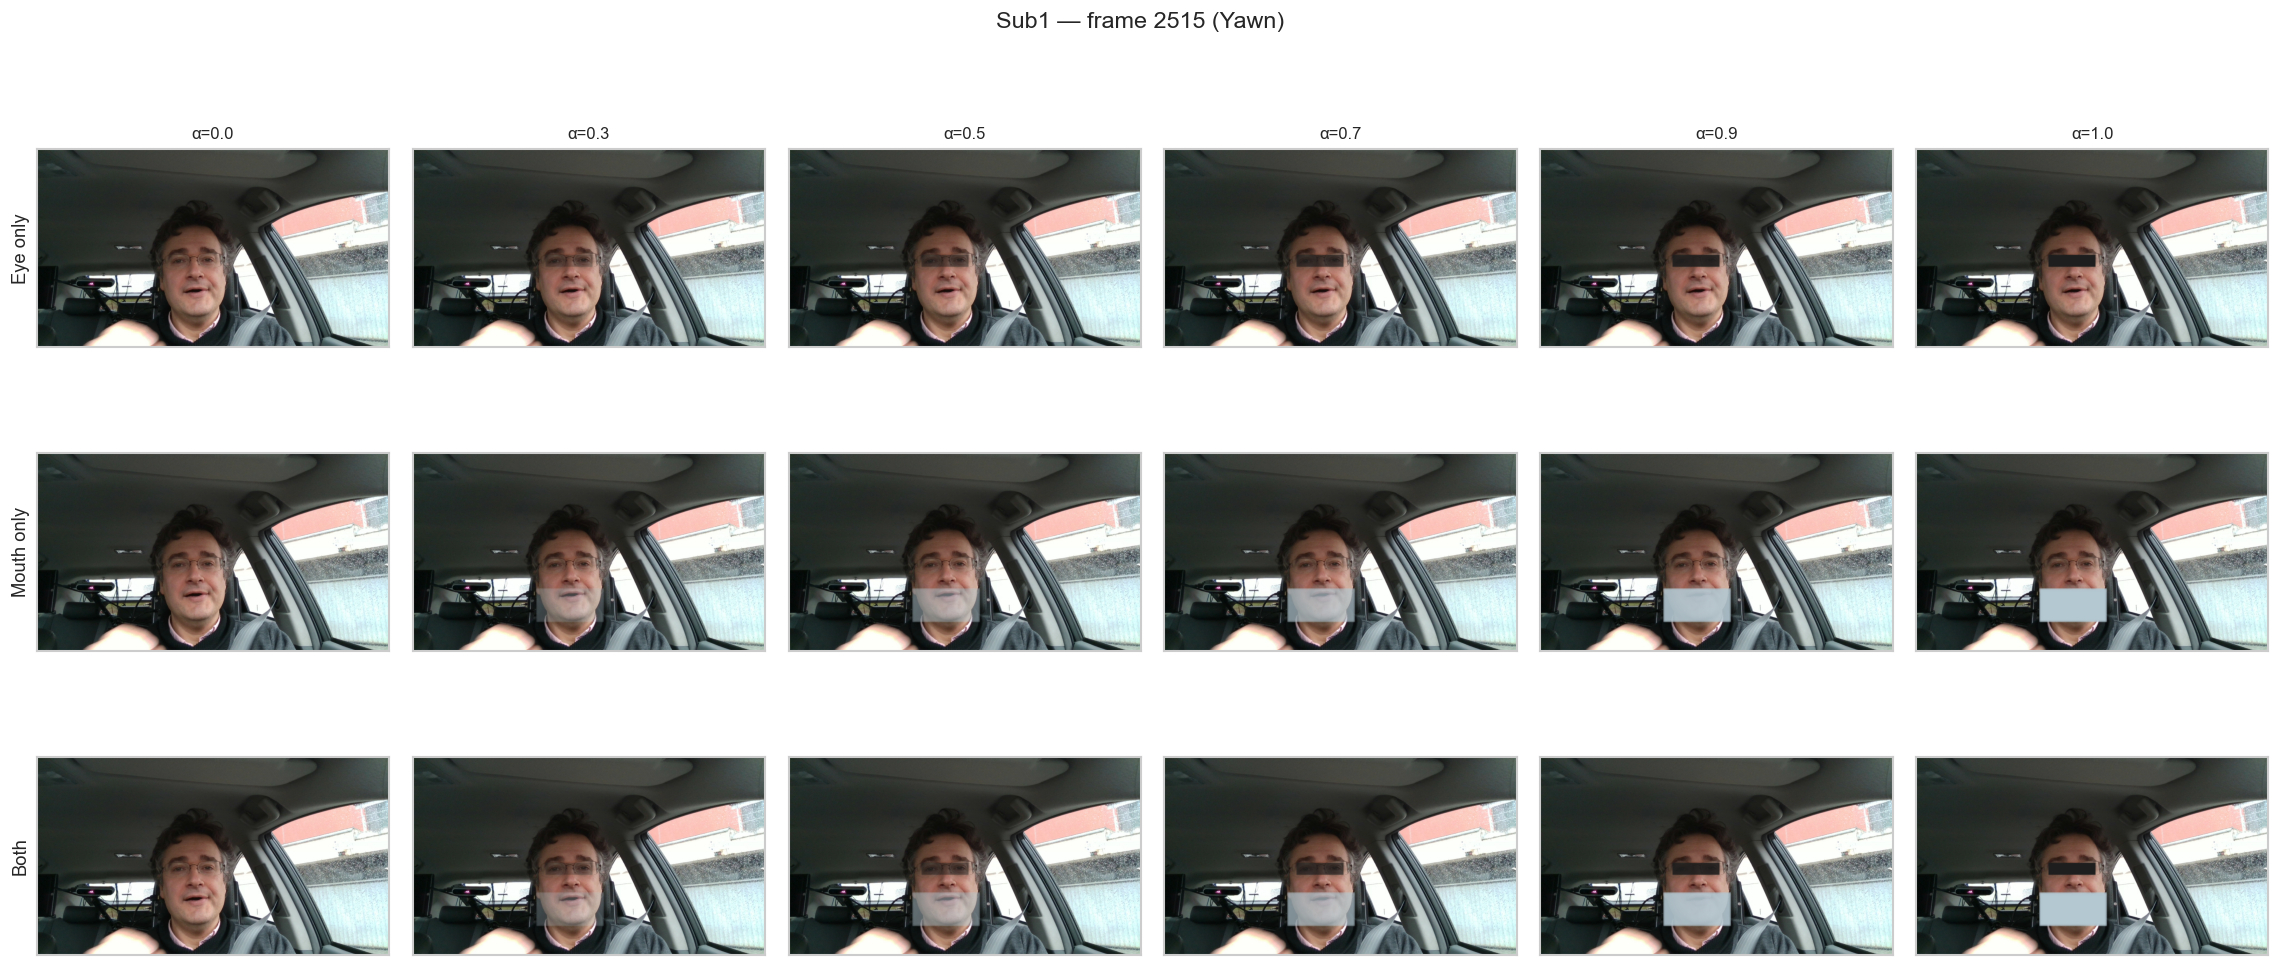

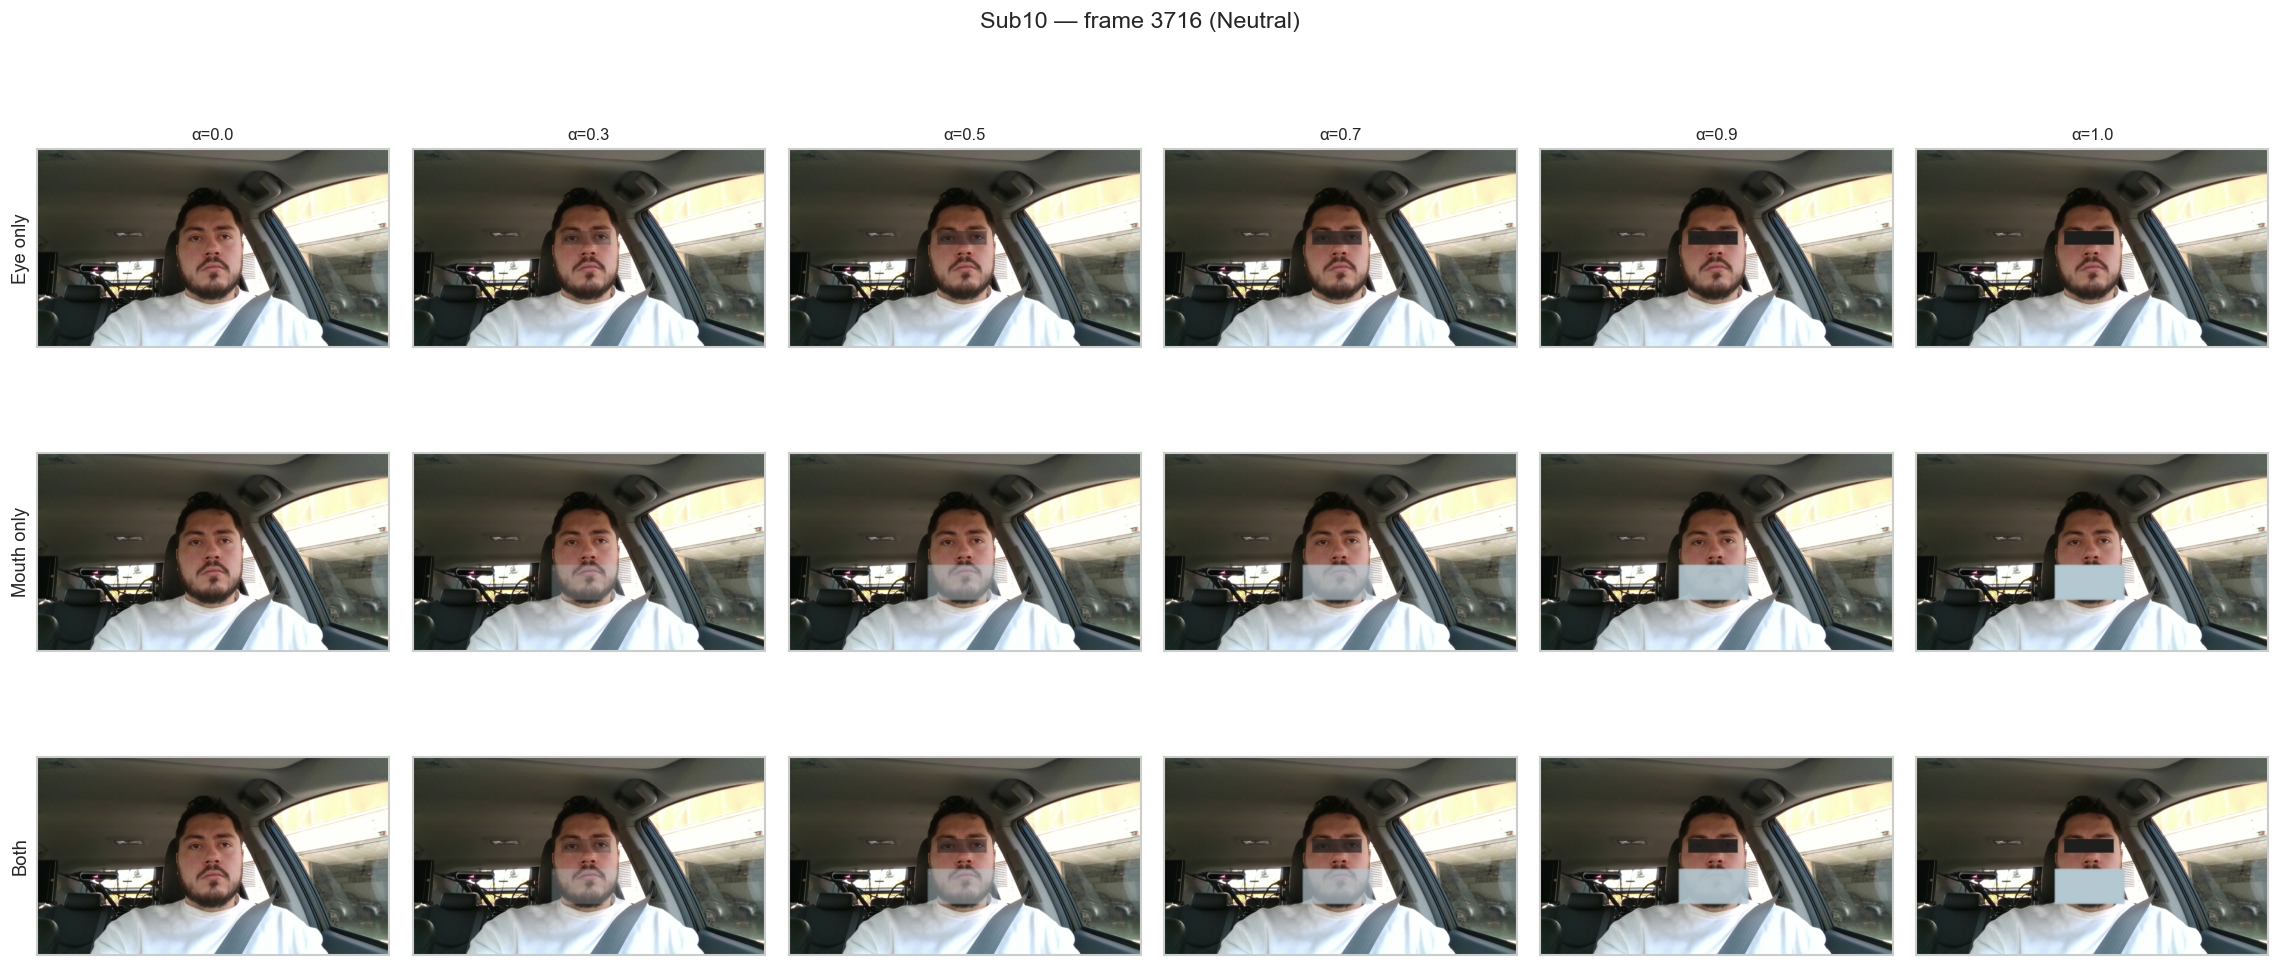

In [7]:
def show_example_occlusions(csv_data, sampled, face_detector, n_examples=2):
    """Visualise a few frames at each opacity level."""
    shown = 0
    for video_key, ann_list in sampled.items():
        if shown >= n_examples:
            break
        meta = csv_data[video_key]
        cap = cv2.VideoCapture(meta['video_path'])
        if not cap.isOpened():
            continue

        ann = ann_list[len(ann_list) // 2]
        cap.set(cv2.CAP_PROP_POS_FRAMES, ann.frame)
        ret, frame_bgr = cap.read()
        cap.release()
        if not ret:
            continue

        det = face_detector.detect_face_and_landmarks(frame_bgr)
        if not det['is_valid']:
            continue

        landmarks = det['landmarks']
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

        fig, axes = plt.subplots(3, len(OPACITY_LEVELS), figsize=(3.2 * len(OPACITY_LEVELS), 9))
        fig.suptitle(f"{meta['subject']} — frame {ann.frame} ({ann.class_label})", fontsize=14)

        for col, opacity in enumerate(OPACITY_LEVELS):
            for row, (label, eo, mo) in enumerate([
                ('Eye only', opacity, 0.0),
                ('Mouth only', 0.0, opacity),
                ('Both', opacity, opacity),
            ]):
                aug = apply_synthetic_occlusion(frame_rgb, landmarks,
                                               eye_opacity=eo, mouth_opacity=mo)
                ax = axes[row, col]
                ax.imshow(aug)
                ax.set_xticks([])
                ax.set_yticks([])
                if col == 0:
                    ax.set_ylabel(label, fontsize=11)
                if row == 0:
                    ax.set_title(f"α={opacity:.1f}", fontsize=10)

        plt.tight_layout()
        plt.savefig(f'output/synth_occ_example_{meta["subject"]}.png', bbox_inches='tight')
        plt.show()
        shown += 1

show_example_occlusions(csv_data, sampled, face_detector, n_examples=2)

## 5. Estimator Response Curves

**Core question:** How do `p_eye` and `p_mouth` change as we increase synthetic occlusion opacity?

For each occlusion type (eye-only, mouth-only, both) we plot the mean predicted probability as a function of opacity.

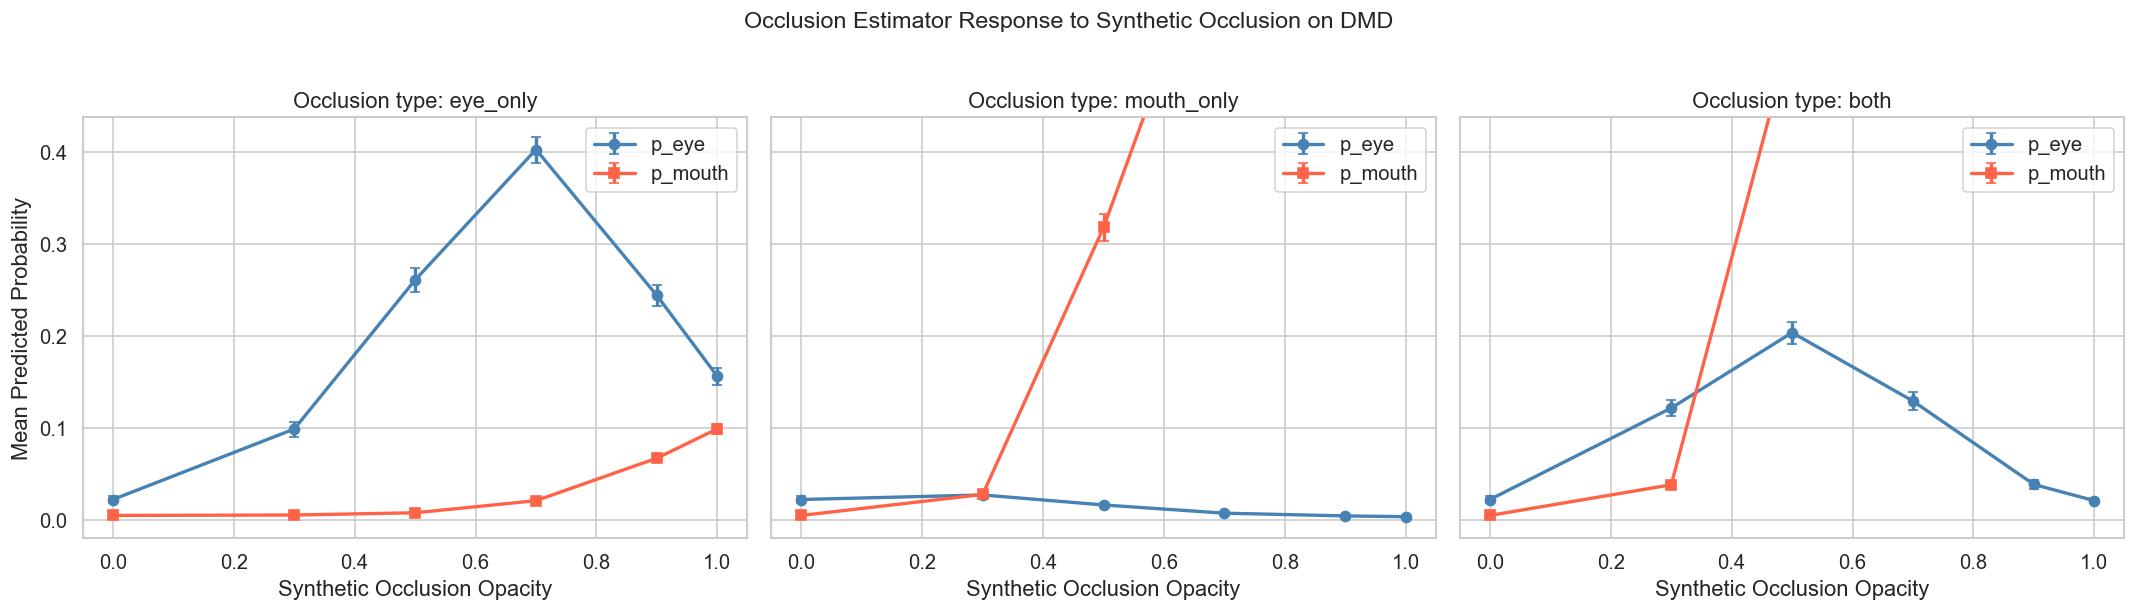

In [8]:
# Reload from CSV if needed
# df = pd.read_csv('synthetic_occlusion_results.csv')

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for idx, occ_type in enumerate(['eye_only', 'mouth_only', 'both']):
    subset = df[df['occlusion_type'].isin([occ_type, 'none'])].copy()
    subset.loc[subset['occlusion_type'] == 'none', 'opacity'] = 0.0

    stats = subset.groupby('opacity').agg(
        p_eye_mean=('p_eye', 'mean'),
        p_eye_std=('p_eye', 'std'),
        p_mouth_mean=('p_mouth', 'mean'),
        p_mouth_std=('p_mouth', 'std'),
        n=('p_eye', 'count'),
    ).reset_index()

    ax = axes[idx]
    ax.errorbar(stats['opacity'], stats['p_eye_mean'],
                yerr=stats['p_eye_std'] / np.sqrt(stats['n']),
                marker='o', capsize=3, label='p_eye', color='steelblue', linewidth=2)
    ax.errorbar(stats['opacity'], stats['p_mouth_mean'],
                yerr=stats['p_mouth_std'] / np.sqrt(stats['n']),
                marker='s', capsize=3, label='p_mouth', color='tomato', linewidth=2)

    ax.set_xlabel('Synthetic Occlusion Opacity')
    ax.set_title(f'Occlusion type: {occ_type}')
    ax.legend()
    ax.set_ylim(bottom=-0.02)

axes[0].set_ylabel('Mean Predicted Probability')
plt.suptitle('Occlusion Estimator Response to Synthetic Occlusion on DMD', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('output/synth_occ_response_curves.png', bbox_inches='tight')
plt.show()

## 6. Region Specificity Analysis

A well-behaved estimator should show:
- Eye-only occlusion → `p_eye` ↑, `p_mouth` ≈ unchanged
- Mouth-only occlusion → `p_mouth` ↑, `p_eye` ≈ unchanged

We measure the *cross-talk* between the two heads.

In [9]:
# Get baseline (no occlusion) per frame
baseline = df[df['occlusion_type'] == 'none'][['video_key', 'frame', 'p_eye', 'p_mouth']].copy()
baseline = baseline.rename(columns={'p_eye': 'p_eye_base', 'p_mouth': 'p_mouth_base'})

augmented = df[df['occlusion_type'] != 'none'].copy()
augmented = augmented.merge(baseline, on=['video_key', 'frame'], how='left')

augmented['delta_p_eye'] = augmented['p_eye'] - augmented['p_eye_base']
augmented['delta_p_mouth'] = augmented['p_mouth'] - augmented['p_mouth_base']

print("Mean delta (augmented − baseline):")
summary = augmented.groupby(['occlusion_type', 'opacity']).agg(
    delta_eye_mean=('delta_p_eye', 'mean'),
    delta_mouth_mean=('delta_p_mouth', 'mean'),
    n=('delta_p_eye', 'count'),
).reset_index()

print(summary.to_string(index=False))

Mean delta (augmented − baseline):
occlusion_type  opacity  delta_eye_mean  delta_mouth_mean   n
          both      0.3        0.099463          0.033346 450
          both      0.5        0.181443          0.526640 450
          both      0.7        0.107028          0.886566 450
          both      0.9        0.016415          0.979126 450
          both      1.0       -0.001237          0.985424 450
      eye_only      0.3        0.076615          0.000478 450
      eye_only      0.5        0.238608          0.002898 450
      eye_only      0.7        0.380477          0.016055 450
      eye_only      0.9        0.221872          0.062255 450
      eye_only      1.0        0.134022          0.094112 450
    mouth_only      0.3        0.004944          0.022831 450
    mouth_only      0.5       -0.005941          0.313252 450
    mouth_only      0.7       -0.014863          0.674271 450
    mouth_only      0.9       -0.017836          0.820415 450
    mouth_only      1.0       -0.01

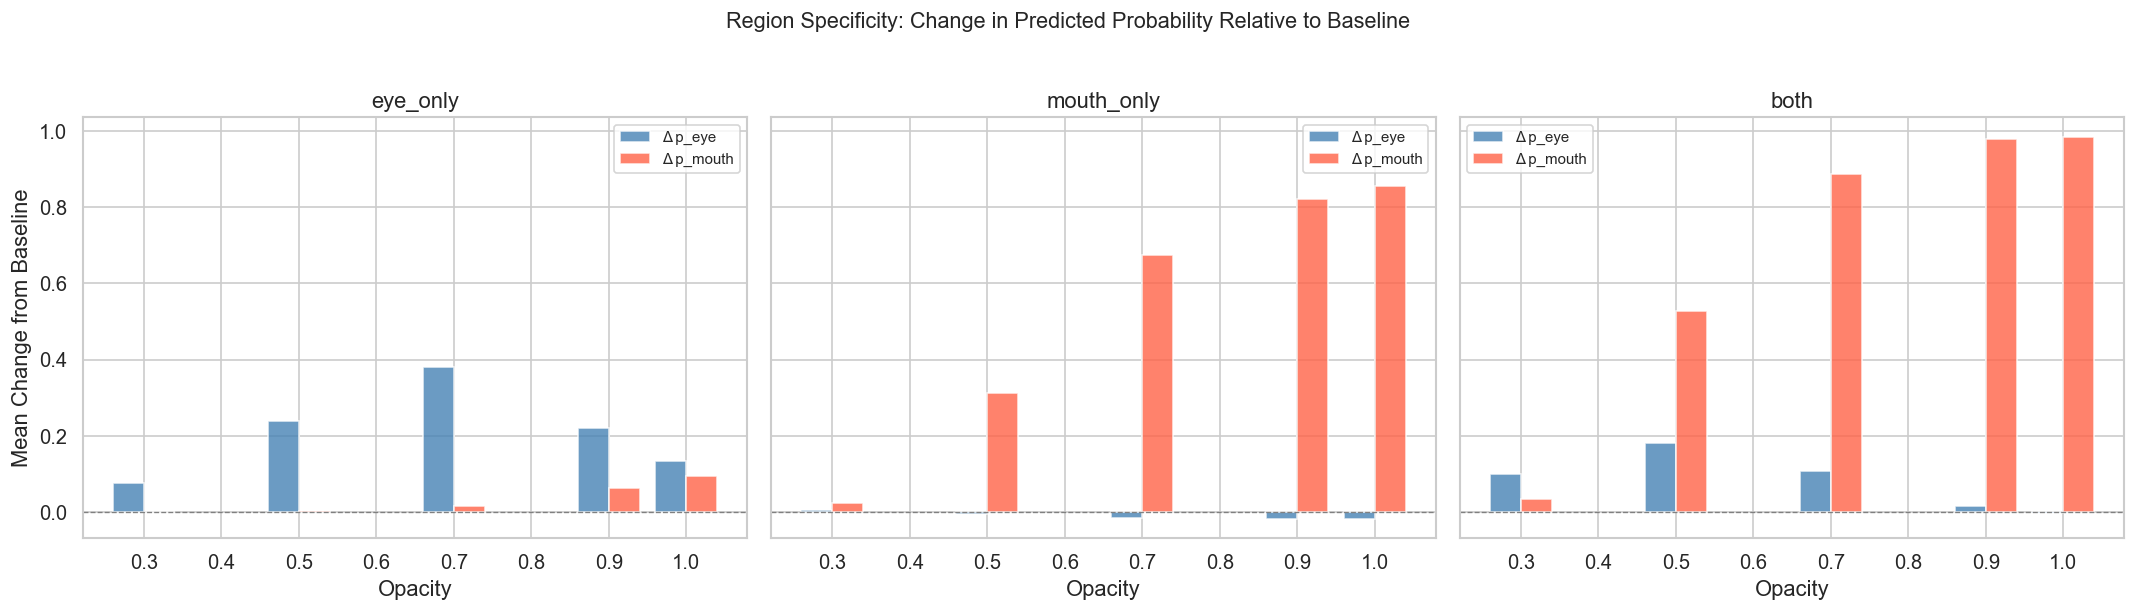

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for idx, occ_type in enumerate(['eye_only', 'mouth_only', 'both']):
    sub = summary[summary['occlusion_type'] == occ_type]
    ax = axes[idx]

    ax.bar(sub['opacity'] - 0.02, sub['delta_eye_mean'],
           width=0.04, label='Δ p_eye', color='steelblue', alpha=0.8)
    ax.bar(sub['opacity'] + 0.02, sub['delta_mouth_mean'],
           width=0.04, label='Δ p_mouth', color='tomato', alpha=0.8)

    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Opacity')
    ax.set_title(f'{occ_type}')
    ax.legend(fontsize=9)

axes[0].set_ylabel('Mean Change from Baseline')
plt.suptitle('Region Specificity: Change in Predicted Probability Relative to Baseline',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('output/synth_occ_region_specificity.png', bbox_inches='tight')
plt.show()

## 7. Per-Subject Response

Does the estimator response vary across subjects (different face shapes, lighting, etc.)?

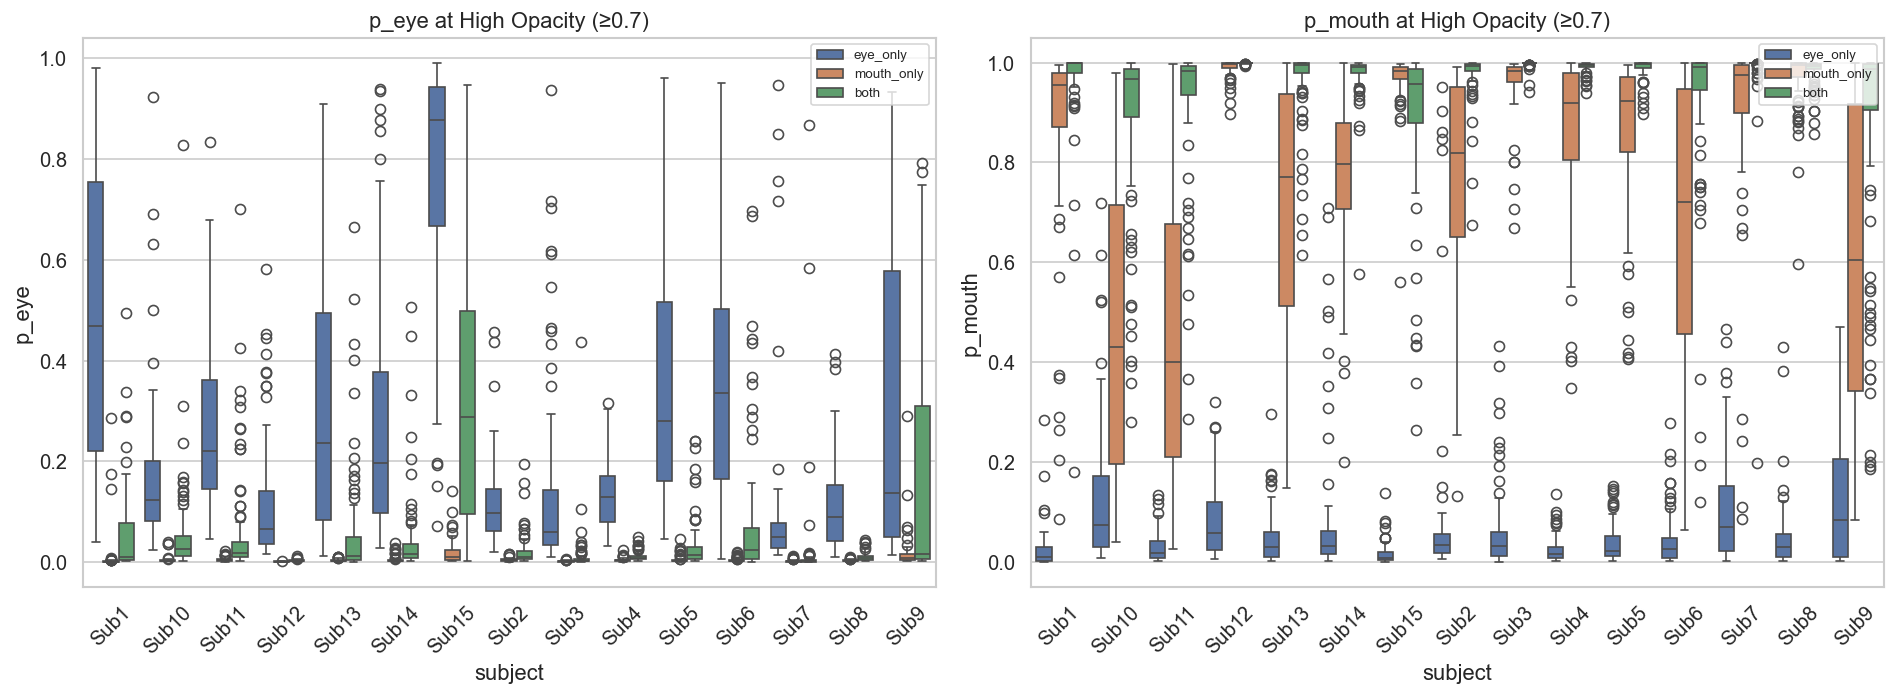

In [11]:
high_opacity = df[df['opacity'] >= 0.7].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (prob_col, title) in enumerate([
    ('p_eye', 'p_eye at High Opacity (≥0.7)'),
    ('p_mouth', 'p_mouth at High Opacity (≥0.7)'),
]):
    ax = axes[idx]
    sub = high_opacity[high_opacity['occlusion_type'] != 'none']
    sns.boxplot(data=sub, x='subject', y=prob_col, hue='occlusion_type', ax=ax)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('output/synth_occ_per_subject.png', bbox_inches='tight')
plt.show()

## 8. Summary Statistics

In [12]:
print("=" * 70)
print("SYNTHETIC OCCLUSION EXPERIMENT: SUMMARY")
print("=" * 70)

n_frames = df[df['occlusion_type'] == 'none'].shape[0]
n_subjects = df['subject'].nunique()
print(f"\nFrames analysed: {n_frames} from {n_subjects} subjects")
print(f"Opacity levels tested: {sorted(df['opacity'].unique())}")

print("\n--- Baseline (no synthetic occlusion) ---")
base = df[df['occlusion_type'] == 'none']
print(f"  Mean p_eye:   {base['p_eye'].mean():.4f}")
print(f"  Mean p_mouth: {base['p_mouth'].mean():.4f}")

print("\n--- At Maximum Opacity (1.0) ---")
for occ_type in ['eye_only', 'mouth_only', 'both']:
    sub = df[(df['occlusion_type'] == occ_type) & (df['opacity'] == 1.0)]
    if len(sub) == 0:
        continue
    print(f"  {occ_type}:")
    print(f"    p_eye  = {sub['p_eye'].mean():.4f}  (baseline {base['p_eye'].mean():.4f}, Δ = {sub['p_eye'].mean() - base['p_eye'].mean():+.4f})")
    print(f"    p_mouth = {sub['p_mouth'].mean():.4f}  (baseline {base['p_mouth'].mean():.4f}, Δ = {sub['p_mouth'].mean() - base['p_mouth'].mean():+.4f})")

print("\n--- Interpretation for Journal ---")
print("  If p_eye rises substantially with eye_only occlusion:")
print("    → The estimator CAN detect occlusion when it matches training domain (ROF).")
print("    → The low AUC on natural DMD is a domain gap, NOT an architecture failure.")
print("  If p_mouth rises substantially with mouth_only occlusion:")
print("    → Same conclusion for mouth occlusion.")
print("  If cross-talk is low (eye occlusion doesn't raise p_mouth much):")
print("    → The two heads are region-specific — supporting the gating design.")
print("  If cross-talk is high:")
print("    → The estimator uses holistic cues, not region-specific ones.")

SYNTHETIC OCCLUSION EXPERIMENT: SUMMARY

Frames analysed: 450 from 15 subjects
Opacity levels tested: [np.float64(0.0), np.float64(0.3), np.float64(0.5), np.float64(0.7), np.float64(0.9), np.float64(1.0)]

--- Baseline (no synthetic occlusion) ---
  Mean p_eye:   0.0223
  Mean p_mouth: 0.0050

--- At Maximum Opacity (1.0) ---
  eye_only:
    p_eye  = 0.1563  (baseline 0.0223, Δ = +0.1340)
    p_mouth = 0.0991  (baseline 0.0050, Δ = +0.0941)
  mouth_only:
    p_eye  = 0.0036  (baseline 0.0223, Δ = -0.0187)
    p_mouth = 0.8603  (baseline 0.0050, Δ = +0.8553)
  both:
    p_eye  = 0.0211  (baseline 0.0223, Δ = -0.0012)
    p_mouth = 0.9904  (baseline 0.0050, Δ = +0.9854)

--- Interpretation for Journal ---
  If p_eye rises substantially with eye_only occlusion:
    → The estimator CAN detect occlusion when it matches training domain (ROF).
    → The low AUC on natural DMD is a domain gap, NOT an architecture failure.
  If p_mouth rises substantially with mouth_only occlusion:
    → Same c

In [ ]:
import json

summary_data = {
    'n_frames': int(n_frames),
    'n_subjects': int(n_subjects),
    'opacity_levels': sorted([float(x) for x in df['opacity'].unique()]),
    'baseline_p_eye': float(base['p_eye'].mean()),
    'baseline_p_mouth': float(base['p_mouth'].mean()),
}

for occ_type in ['eye_only', 'mouth_only', 'both']:
    sub = df[(df['occlusion_type'] == occ_type) & (df['opacity'] == 1.0)]
    if len(sub) > 0:
        summary_data[f'{occ_type}_max_p_eye'] = float(sub['p_eye'].mean())
        summary_data[f'{occ_type}_max_p_mouth'] = float(sub['p_mouth'].mean())

with open('synthetic_occlusion_summary.json', 'w') as f:
    json.dump(summary_data, f, indent=2)

print('Saved synthetic_occlusion_summary.json')